feature pyramid是用来检测不同scale的object的1种基本方法。

如图1和图2所示，基于feature pyrimid来检测不同scale的object，共有5种思路：4种已有思路（分别缩写为ABCD）和本文思路（FPN）

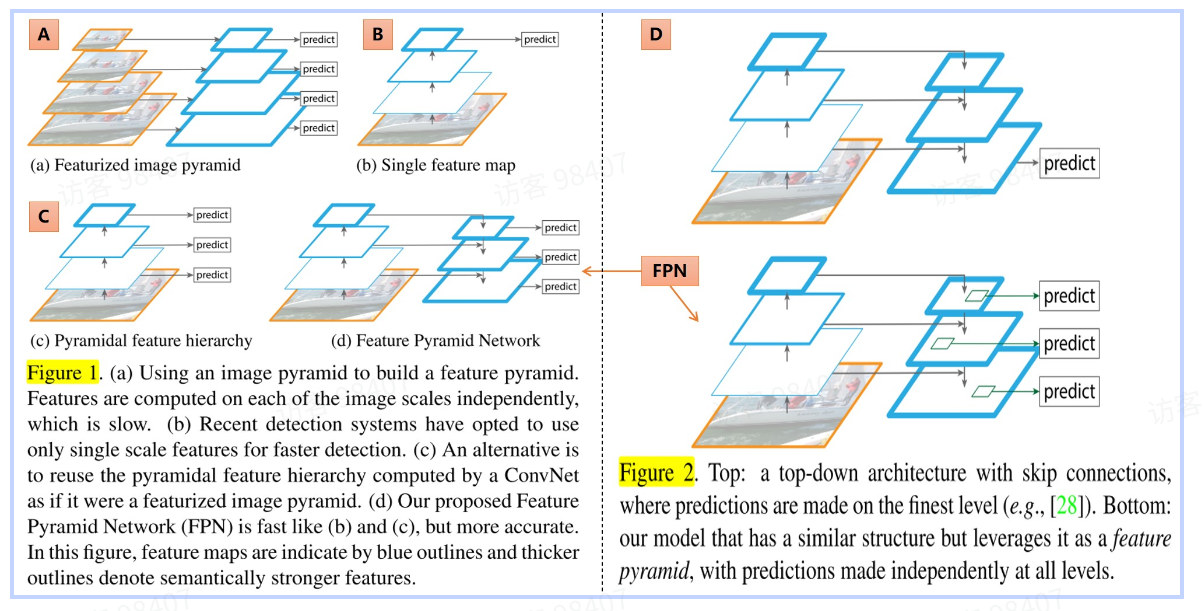


| 缩写 | 图片    | 名称                        |
| :--: | :------ | :-------------------------- |
| A    | 图1(a)  | Featurized image pyramid    |
| B    | 图1(b)  | Single feature map          |
| C    | 图1(c)  | Pyramidal feature hierarchy |
| D    | 图2(top)| Methods using multiple layers |
| FPN  | 图1(d)、图2(bottom) | Feature Pyramid Network |




| 方法 | 定义 | 优点 | 缺点 | 应用 |
| :--: | :-- | :-- | :-- | :-- |
| **A** | 即feature pyramids built upon image pyramids。先将image缩放到不同scale建立image pyramid，再分别提取特征并分别进行检测。 | 每个level都具有很强的high-level semantic feature，即使是high-resolution level。 | ①每个level分别提取特征并分别检测，推理时间相应加倍；<br>②考虑到内存等因素，不可能端到端地在image pyramid上训练卷积网络，最多只能在测试的时候使用image pyramid（同时这也造成训练和测试的不一致性）。因为这些原因，Fast和Faster R-CNN默认也就没有使用featurized image pyramid。 | 大量应用于基于手工特征（HOG、SIFT）的算法，比如DPM；OverFeat将卷积网络作为sliding window应用于image pyramid。 |
| **B** | 在卷积网络最后的单个feature map上进行检测。 | ①卷积网络可以表示high-level semantic，对于scale的variance比较robust；<br>②因为在1个level上进行检测，所以速度相对较快。 | 没有使用可以提升性能的pyramid。 | SPPNet、Fast RCNN、Faster RCNN。 |
| **C** | 使用卷积网络固有的pyramid hierarchy，在不同level的feature map上分别进行检测。 | 使用了卷积网络固有的pyramid hierarchy。 | 不同level之间存在语义差异，high-resolution map中的low-level feature降低了该level在OD中的表征能力。 | 理想情况下应该利用forward pass中生成的多尺度特征，但SSD为了避免使用低级特征就没有利用high-resolution map而是在网络深层之后添加几个层以构建pyramid。但本文（FPN）证明high-resolution map对检测small object很重要。 |
| **D** | 使用skip connection将low-level feature和high-level feature融合，构建出top-down path，最终在最后1个level进行检测。 | ①使用多层特征；<br>②使用skip connection将low-level feature和high-level feature融合。 | 这些使用skip connection的方法仅在top-down path的最后1层进行检测，仍需要image pyramid。 | ①FCN、HyperNet、ParseNet、ION、SSD、MS-CNN都使用了多层特征；<br>②U-Net、SharpMask、Recombinator networks、Stacked Hourglass networks使用skip connection将low-level feature和high-level feature融合。 |
| **FPN** | 使用skip connection将low-level feature和high-level feature融合，构建出top-down path，最终在多个level进行检测。 | 在top-down path的多个level独立进行检测。 | （原文未提及缺点，保留空白） | （原文未提及应用，保留空白） |




---

## FPN（Feature Pyramid Network）要点整理

### 一、问题背景
- **feature pyramid** 是检测不同尺度（scale）目标的基本方法。
- 但近期的深度学习检测器（如 RCNN、SPPNet、Fast RCNN、Faster RCNN）均**未使用** pyramid representation（即在多个尺度特征图上进行检测）。
- 未使用的主要原因：计算量大、内存消耗高。

---

### 二、方法 / 研究内容
- FPN 基于 CNN **固有的 pyramid hierarchy**，利用 **skip connection** 构建 **top-down path**。
- 仅需少量额外成本即可生成 feature pyramid，且 pyramid 中**每个尺度（level）都具有 high‑level semantic feature**。
- 最终在 feature pyramid 的各个 level 上独立进行目标检测。

---

### 三、创新点 / 优点
1. **重新引入 pyramid**：在深度学习检测器中构建 feature pyramid，弥补了近期主流方法（RCNN 系列）的缺失。
2. **高效**：计算成本低，且每个 level 均具备高语义特征。
3. **速度快、精度高**。
4. **通用性强（generic）**：
   - 不依赖于特定骨干网络；
   - 可应用于多种算法改进，本文将其用于：
     - Faster RCNN（包括 RPN 和 Fast RCNN 部分）
     - Instance segmentation proposals

---

### 四、性能 / 效果
- **准确度**：达到 SOTA，将 FPN 应用于 Faster RCNN 后，在 COCO 检测任务上**超过所有 single‑model**。
- **速度**：GPU 上可达 **6 FPS**。

---

### 五、不足（被后续工作指出的问题）
- **PoolNet** 指出：top‑down 路径中，**高级语义信息会逐渐稀释**。
- **Libra RCNN** 指出：FPN 采用 **sequential manner**（顺序融合方式），使得融合后的特征**更关注相邻层**，而对**非相邻层**关注不足；每次融合时，非相邻层的语义信息会被进一步稀释。

---



---

## FPN 算法流程（完整版）

### 一、总体概述
- **输入**：任意尺度的单张图片  
- **输出**：在多个 level（层级）输出对应尺寸的特征图（feature map）  
- **构建方式**：包括 **bottom‑up path**（自底向上路径）、**top‑down path**（自顶向下路径）和 **skip connection**（横向连接，或称侧向连接）

---

### 二、Bottom‑up path（自底向上路径）
- **本质**：bottom‑up path 就是 backbone 的前向传播（feedforward）。
- **stage 划分**：
  - 将 backbone 划分为多个 stage，**每个 stage 定义为一个 pyramid level**。
  - 每个 stage 内所有层输出的特征图尺寸相同，取 **该 stage 最后一层**的输出作为该 stage 的最终输出——因为每个 stage 中最深的层应具有最强的特征表达能力。
  - 相邻 stage 之间的下采样比例为 **2**（即尺寸减半）。

- **以 ResNet 为例**：
  - 使用 ResNet 的**后 4 个 stage**，即 {C₂, C₃, C₄, C₅}，它们相对于输入图像的下采样比例分别为 **4、8、16、32**。
  - 将这四个 stage 的输出作为 FPN 的 4 个 pyramid level。
  - **不包含第 1 个 stage**（C₁），因为其内存占用量较大。

---

### 三、Top‑down path（自顶向下路径）
- **动机**：
  - 高层语义信息（high‑level semantic）有助于识别目标，但不利于精确定位；
  - 低层空间信息（low‑level spatial）有利于定位（下采样少，位置更精确），但不利于识别。
  - 因此需将高层语义与低层空间信息融合。

- **构建方式**：通过 **skip connection（横向连接）** 将 bottom‑up 的特征传递到 top‑down 路径。

- **注意事项**：
  - 在开始 top‑down 路径之前，**先对 bottom‑up 的最顶层（C₅）使用 1×1 卷积**，生成最粗糙分辨率（coarsest resolution）的特征图，作为 top‑down 的起点。

---

### 四、Skip connection（横向连接）的具体操作
每个横向连接块（如图 Figure 3 所示）包含以下三步：

1. **上采样**：将来自 top‑down 路径的较粗糙（coarser‑resolution）特征图进行 **2 倍上采样**。简单起见，使用 **最近邻插值（nearest neighbor upsampling）**。

2. **降通道**：使用 **1×1 卷积** 减少来自 bottom‑up 路径对应特征图的通道数，使其与 top‑down 路径的通道数一致。

3. **逐元素相加（element‑wise addition）**：将上述两者（尺寸和通道数均相同）的特征图相加。



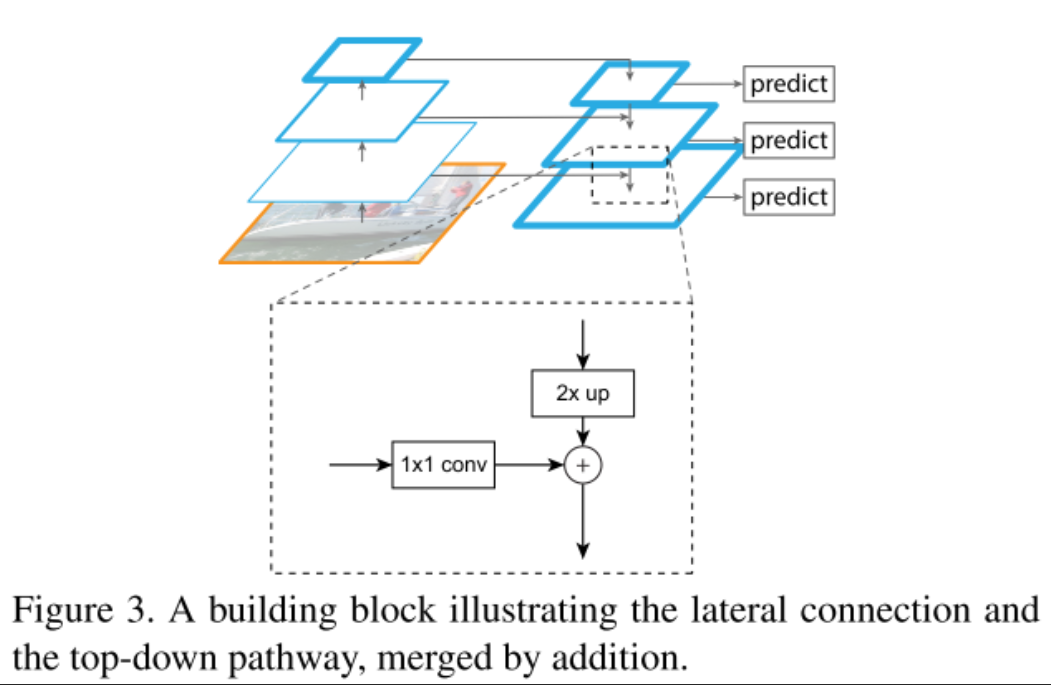

---

### 五、最终输出
- top‑down 路径经过逐级融合后，得到 **{P₂, P₃, P₄, P₅}**，它们分别与 bottom‑up 的 {C₂, C₃, C₄, C₅} 对应，且 **空间尺寸相同**（分辨率分别为输入的 1/4、1/8、1/16、1/32）。

- 在每个相加后的特征图上，再应用一个 **3×3 卷积**，得到最终的 FPN 输出。
  - **作用**：减少上采样带来的 **aliasing effect（混叠效应）**。
    - *注：原文标注 TODO，明确 aliasing effect 是什么以及 3×3 卷积为何能缓解，作者实验发现加不加 3×3 影响很小。*
  - **激活函数**：该 3×3 卷积**后不接非线性激活函数**（作者实验表明加激活函数影响不大）。

---

### 六、用于 RPN（区域提议网络）的相关设置
以下内容针对 FPN 与 Faster RCNN 中 RPN 结合时的配置：

- **Anchor 设计**：每个 level 上均使用 **3 种长宽比（aspect ratio）** 的 anchor，即 **1:2、1:1、2:1**。

- **训练标签分配（正负样本）**：
  - **正样本**：与某个 GT BBox 的 IoU 最大的 anchor；或与某个 GT BBox 的 IoU **大于 0.7** 的 anchor。
  - **负样本**：与**所有** GT BBox 的 IoU 都 **小于 0.3** 的 anchor。

- **GT BBox 分配到哪个 pyramid level？**
  - 并非根据 GT BBox 本身的尺度（scale）来分配 level，而是**通过 anchor 来对应**——不同尺度的 anchor 已被固定分配到某个 level，GT 会根据与 anchor 的 IoU 匹配而自然地落到相应 level。

- **多个 RPN 头（multi RPN）**：
  - 如果每个 level 使用不同的 RPN 分支，准确度与共享 RPN 相似。
  - 这表明 pyramid 的各个 level **共享相似的语义层级**，这一优势类似于 featurized image pyramid（即一个通用的分类器可应用于不同尺度图像提取的特征）。

---


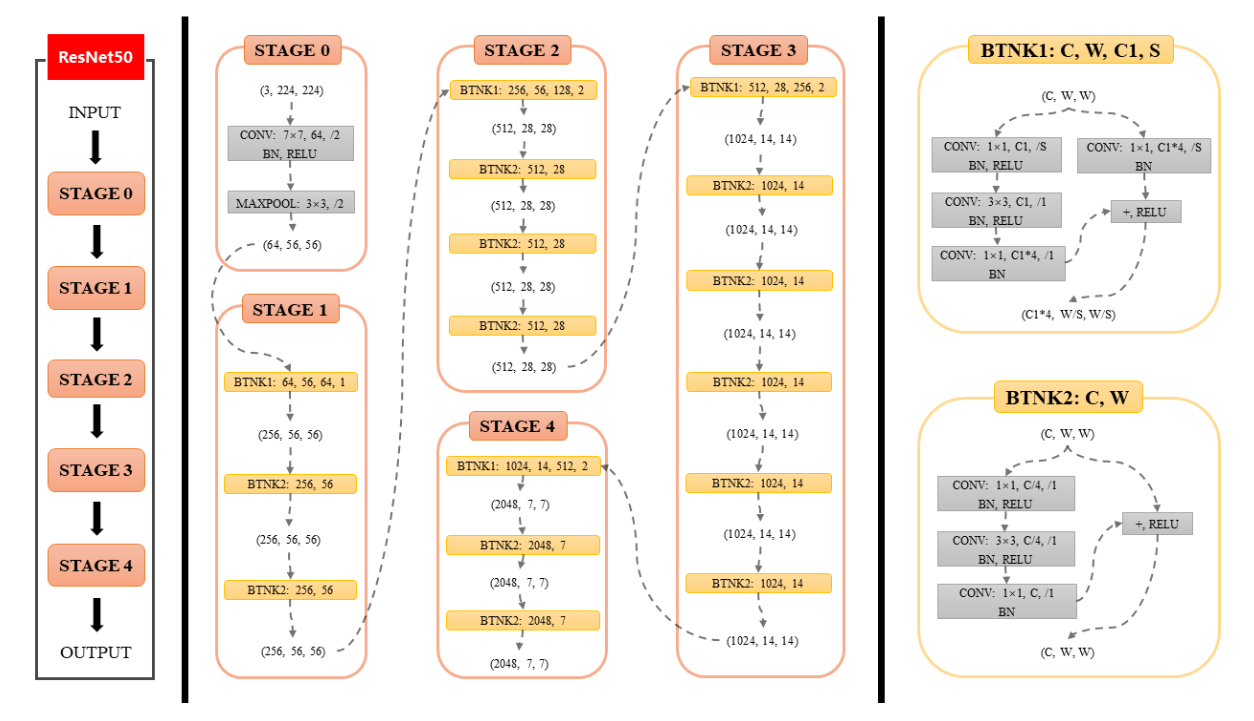

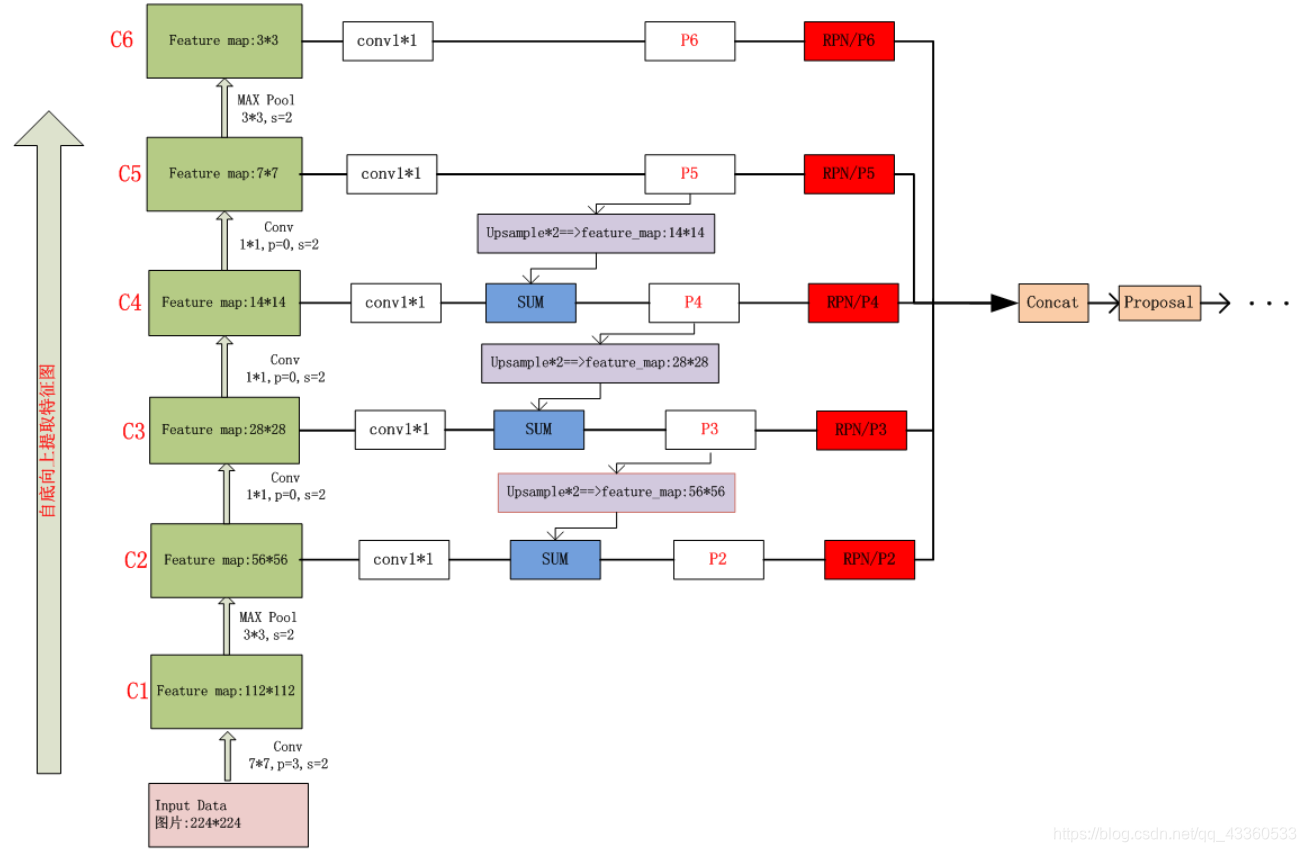

In [ ]:
# 导入必要的库
import torch.nn as nn
import torch.nn.functional as F
import math

# 定义模块导出列表
__all__=['FPN']

class Bottleneck(nn.Module):
    """ResNet 瓶颈块（Bottleneck Block）
    
    结构：1x1 卷积 -> 3x3 卷积 -> 1x1 卷积
    第一个 1x1 卷积用于降维，3x3 卷积提取特征，最后一个 1x1 卷积升维
    expansion=4 表示输出通道数是中间层通道数的 4 倍
    
    输入/输出张量形状:
        输入：(batch_size, in_planes, H, W)
        输出：(batch_size, expansion * planes, H', W')
        - 如果 stride=1，则 H'=H, W'=W
        - 如果 stride=2，则 H'=H/2, W'=W/2
    """
    expansion = 4  # 输出通道扩展倍数

    def __init__(self, in_planes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        # 第一个 1x1 卷积：降维
        # 输入：(batch, in_planes, H, W) -> 输出：(batch, planes, H, W) (stride=1)
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        
        # 第二个 3x3 卷积：提取特征，可能进行下采样
        # 输入：(batch, planes, H, W) -> 输出：(batch, planes, H/stride, W/stride)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        
        # 第三个 1x1 卷积：升维到 expansion * planes
        # 输入：(batch, planes, H/stride, W/stride) -> 输出：(batch, expansion*planes, H/stride, W/stride)
        self.conv3 = nn.Conv2d(planes, self.expansion * planes, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.expansion * planes)
        
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample  # 残差连接的下采样模块（当需要改变通道数或尺寸时使用）
        self.stride = stride
        

    def forward(self, x):
        """前向传播
        
        参数:
            x: 输入张量，形状 (batch_size, in_planes, H, W)
        返回:
            out: 输出张量，形状 (batch_size, expansion*planes, H/stride, W/stride)
        """
        residual = x  # 保存残差连接
        
        # 第一个卷积块：1x1 卷积降维
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        # 第二个卷积块：3x3 卷积提取特征
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        
        # 第三个卷积块：1x1 卷积升维
        out = self.conv3(out)
        out = self.bn3(out)

        # 如果需要对残差边进行下采样或改变通道数
        if self.downsample is not None:
            residual = self.downsample(x)
        
        # 残差连接：主路径输出 + 残差边
        out += residual
        out = self.relu(out)
        
        return out

In [ ]:

class FPN(nn.Module):
    """Feature Pyramid Network (特征金字塔网络)
    
    结构包含:
        1. Bottom-up path: ResNet-50/101 作为骨干网络，提取多尺度特征 {C2, C3, C4, C5}
        2. Top-down path: 从最顶层 C5 开始，逐层上采样并与底层特征融合
        3. Lateral connections: 1x1 卷积调整底层特征通道数，便于融合
        4. Smooth layers: 3x3 卷积减少上采样的混叠效应
    
    输入/输出张量形状:
        输入：x - (batch_size, 3, H, W) RGB 三通道图像
        输出：(p2, p3, p4, p5) - 4 个尺度的特征图
            - p2: (batch, 256, H/4, W/4)   最高分辨率，用于检测小目标
            - p3: (batch, 256, H/8, W/8)
            - p4: (batch, 256, H/16, W/16)
            - p5: (batch, 256, H/32, W/32) 最低分辨率，语义信息最强
    """
    def __init__(self, block, layers):
        super(FPN, self).__init__()
        self.inplanes = 64  # 初始通道数

        # Stem: 初始卷积层
        # 输入：(batch, 3, H, W) -> 输出：(batch, 64, H/2, W/2)
        # kernel_size=7, stride=2, padding=3 保持输出尺寸为输入的一半
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.relu = nn.ReLU(inplace=True)
        # 最大池化：进一步减半尺寸
        # 输入：(batch, 64, H/2, W/2) -> 输出：(batch, 64, H/4, W/4)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Bottom-up layers: ResNet 的 4 个 stage，输出多尺度特征 {C2, C3, C4, C5}
        # layer1: 输入 (batch, 64, H/4, W/4) -> 输出 C2 (batch, 256, H/4, W/4)
        self.layer1 = self._make_layer(block,  64, layers[0])
        # layer2: 输入 (batch, 256, H/4, W/4) -> 输出 C3 (batch, 512, H/8, W/8)，stride=2 下采样
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        # layer3: 输入 (batch, 512, H/8, W/8) -> 输出 C4 (batch, 1024, H/16, W/16)，stride=2 下采样
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        # layer4: 输入 (batch, 1024, H/16, W/16) -> 输出 C5 (batch, 2048, H/32, W/32)，stride=2 下采样
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        # Top layer: 将 C5 的通道从 2048 降为 256，作为 top-down 路径的起点
        # 输入：C5 (batch, 2048, H/32, W/32) -> 输出：p5 (batch, 256, H/32, W/32)
        self.toplayer = nn.Conv2d(2048, 256, kernel_size=1, stride=1, padding=0)

        # Smooth layers: 3x3 卷积减少上采样的混叠效应（aliasing effect）
        # 通道数保持 256 不变
        self.smooth1 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)  # 用于 p4
        self.smooth2 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)  # 用于 p3
        self.smooth3 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)  # 用于 p2

        # Lateral layers: 1x1 卷积调整底层特征通道数到 256，便于与 top-down 特征融合
        # latlayer1: C4 (batch, 1024, H/16, W/16) -> (batch, 256, H/16, W/16)
        self.latlayer1 = nn.Conv2d(1024, 256, kernel_size=1, stride=1, padding=0)
        # latlayer2: C3 (batch, 512, H/8, W/8) -> (batch, 256, H/8, W/8)
        self.latlayer2 = nn.Conv2d( 512, 256, kernel_size=1, stride=1, padding=0)
        # latlayer3: C2 (batch, 256, H/4, W/4) -> (batch, 256, H/4, W/4)
        self.latlayer3 = nn.Conv2d( 256, 256, kernel_size=1, stride=1, padding=0)
        
        # 权重初始化
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # He 初始化：权重 ~ N(0, sqrt(2/n))
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, nn.BatchNorm2d):
                # BatchNorm 权重初始化为 1，偏置初始化为 0
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def _make_layer(self, block, planes, blocks, stride=1):
        """创建 ResNet 的一个 stage 层
        
        参数:
            block: 瓶颈块类型（Bottleneck）
            planes: 中间层通道数
            blocks: 该 stage 包含的 bottleneck 数量
            stride: 第一个 bottleneck 的 stride（控制是否下采样）
        返回:
            Sequential: 包含多个 bottleneck 的顺序容器
        
        张量形状变换:
            输入：(batch, inplanes, H, W)
            输出：(batch, expansion*planes, H/stride, W/stride)
        """
        downsample = None
        # 当 stride!=1 或通道数改变时，需要对残差边进行下采样
        if stride != 1 or self.inplanes != block.expansion * planes:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, block.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(block.expansion * planes)
            )
        layers = []
        # 添加第一个 bottleneck（可能包含下采样）
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion  # 更新通道数
        # 添加剩余的 bottleneck（stride=1，不改变尺寸）
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def _upsample_add(self, x, y):
        """上采样并逐元素相加（用于 top-down 路径的特征融合）
        
        参数:
            x: 来自 top-down 路径的较粗糙特征图，形状 (batch, 256, H/2s, W/2s)
            y: 来自 lateral connection 的较高分辨率特征图，形状 (batch, 256, H/s, W/s)
        返回:
            融合后的特征图，形状 (batch, 256, H/s, W/s)
        
        张量形状变换:
            1. 获取 y 的空间尺寸：H_out, W_out = y.size()[2:]
            2. 对 x 进行 2 倍双线性上采样：(batch, 256, H/2s, W/2s) -> (batch, 256, H/s, W/s)
            3. 逐元素相加：上采样后的 x + y
        """
        _, _, H, W = y.size()  # 获取目标尺寸（较高分辨率特征图的尺寸）
        # 双线性上采样到目标尺寸，并与 y 相加
        return F.upsample(x, size=(H, W), mode='bilinear') + y

    def forward(self, x):
        """FPN 前向传播
        
        参数:
            x: 输入图像，形状 (batch_size, 3, H, W)
        返回:
            (p2, p3, p4, p5): 4 个尺度的特征金字塔
                - p2: (batch, 256, H/4, W/4)
                - p3: (batch, 256, H/8, W/8)
                - p4: (batch, 256, H/16, W/16)
                - p5: (batch, 256, H/32, W/32)
        
        完整流程:
        1. Bottom-up: 提取多尺度特征 {C2, C3, C4, C5}
        2. Top-down: 从 C5 开始逐层上采样融合
        3. Smooth: 3x3 卷积减少混叠效应
        """
        # ========== Bottom-up path（自底向上路径）==========
        # Stem: 初始卷积和池化
        # 输入：(batch, 3, H, W)
        x = self.conv1(x)      # -> (batch, 64, H/2, W/2)
        x = self.bn1(x)
        x = self.relu(x)
        c1 = self.maxpool(x)   # -> (batch, 64, H/4, W/4)
        
        # ResNet 4 个 stage，输出多尺度特征 {C2, C3, C4, C5}
        c2 = self.layer1(c1)   # C2: (batch, 256, H/4, W/4)
        c3 = self.layer2(c2)   # C3: (batch, 512, H/8, W/8)
        c4 = self.layer3(c3)   # C4: (batch, 1024, H/16, W/16)
        c5 = self.layer4(c4)   # C5: (batch, 2048, H/32, W/32)
        
        # ========== Top-down path（自顶向下路径）==========
        # 从最顶层 C5 开始，逐层上采样并与底层特征融合
        
        # p5: C5 通过 1x1 卷积降通道
        # C5 (batch, 2048, H/32, W/32) -> p5 (batch, 256, H/32, W/32)
        p5 = self.toplayer(c5)
        
        # p4: p5 上采样后与 C4 的 lateral 特征融合
        # p5 (batch, 256, H/32, W/32) 上采样-> (batch, 256, H/16, W/16)
        # C4 (batch, 1024, H/16, W/16) 通过 latlayer1 -> (batch, 256, H/16, W/16)
        # 相加：p4 (batch, 256, H/16, W/16)
        p4 = self._upsample_add(p5, self.latlayer1(c4))
        
        # p3: p4 上采样后与 C3 的 lateral 特征融合
        # p4 (batch, 256, H/16, W/16) 上采样-> (batch, 256, H/8, W/8)
        # C3 (batch, 512, H/8, W/8) 通过 latlayer2 -> (batch, 256, H/8, W/8)
        # 相加：p3 (batch, 256, H/8, W/8)
        p3 = self._upsample_add(p4, self.latlayer2(c3))
        
        # p2: p3 上采样后与 C2 的 lateral 特征融合
        # p3 (batch, 256, H/8, W/8) 上采样-> (batch, 256, H/4, W/4)
        # C2 (batch, 256, H/4, W/4) 通过 latlayer3 -> (batch, 256, H/4, W/4)
        # 相加：p2 (batch, 256, H/4, W/4)
        p2 = self._upsample_add(p3, self.latlayer3(c2))
        
        # ========== Smooth layers（平滑层）==========
        # 3x3 卷积减少上采样带来的混叠效应
        p4 = self.smooth1(p4)  # p4: (batch, 256, H/16, W/16)
        p3 = self.smooth2(p3)  # p3: (batch, 256, H/8, W/8)
        p2 = self.smooth3(p2)  # p2: (batch, 256, H/4, W/4)
        
        # 返回 4 个尺度的特征金字塔
        # p2: 最高分辨率，用于检测小目标
        # p5: 最低分辨率，语义信息最强，用于检测大目标
        return p2, p3, p4, p5


def FPN101():
    """创建 FPN-101 模型（使用 ResNet-101 作为骨干网络）
    
    ResNet-101 的 bottleneck 配置：[3, 4, 23, 3]
    对应 4 个 stage 的 bottleneck 数量
    
    返回:
        FPN 模型实例
    """
    return FPN(Bottleneck, [3, 4, 23, 3])